In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 130

df = pd.read_csv(r'C:\Users\ALG\OneDrive\Documents\olist-ecommerce-analysis\data\cleaned\olist_master.csv')
print(f"Data loaded: {df.shape}")
print(df.head(2))


Data loaded: (96477, 26)
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00           2018-08-07 15:27:45   

  order_estimated_delivery_date                customer_unique_id  \
0                    2017-10-18  7c396fd4830fd04220f754e42b4e5bff   
1                    2018-08-13  af07308b275d755c9edb36a90c618231   

   customer_zip_code_prefix  ... freight_value  \
0                      3149  ...          8.72   
1                     47813  ...         22.76   

          

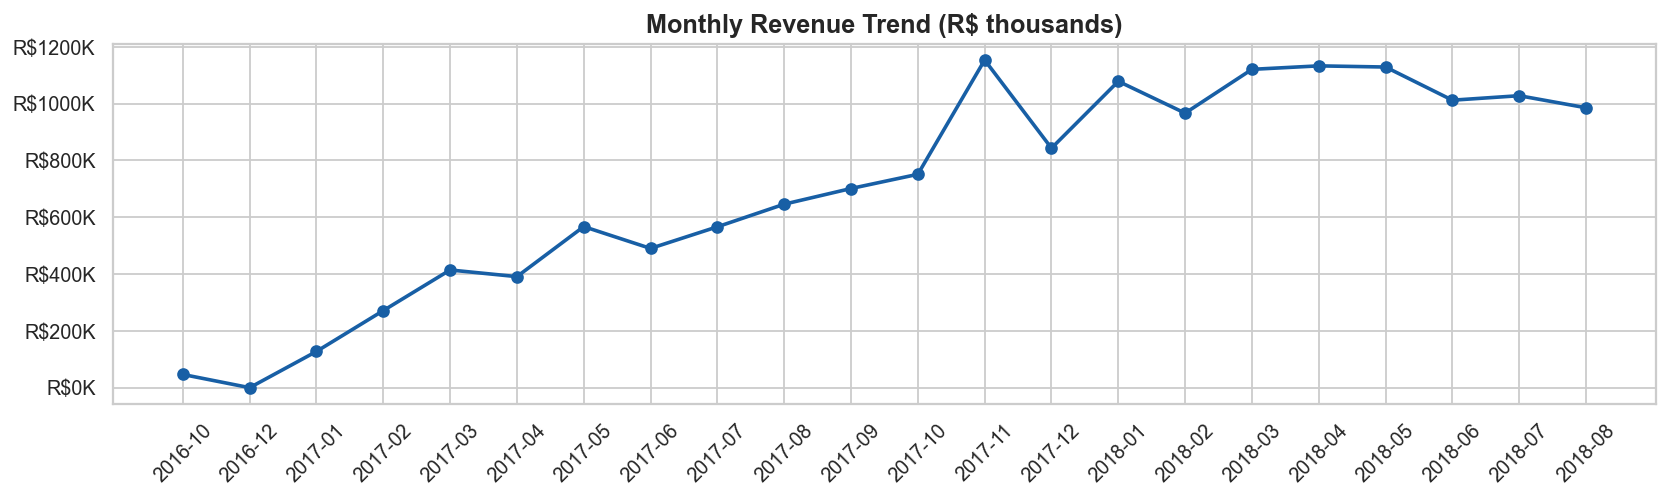

✓ Chart saved!


In [3]:
# Chart 1 - Monthly Revenue Trend
monthly = (df.groupby('order_month')['payment_value']
             .sum().reset_index().sort_values('order_month'))

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(monthly['order_month'], monthly['payment_value']/1000,
        marker='o', color='#185FA5', linewidth=2)
ax.set_title('Monthly Revenue Trend (R$ thousands)', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'R${x:.0f}K'))
plt.tight_layout()
plt.savefig(r'C:\Users\ALG\OneDrive\Documents\olist-ecommerce-analysis\assets\monthly_revenue.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart saved!")

## Finding 1: Revenue Grew 10x in 2 Years
Olist revenue grew from R$8K/month (Oct 2016) to over R$1M/month (mid-2018).
January 2018 shows a seasonal dip — typical post-holiday slowdown.
This indicates strong platform adoption and seller growth over 2 years.

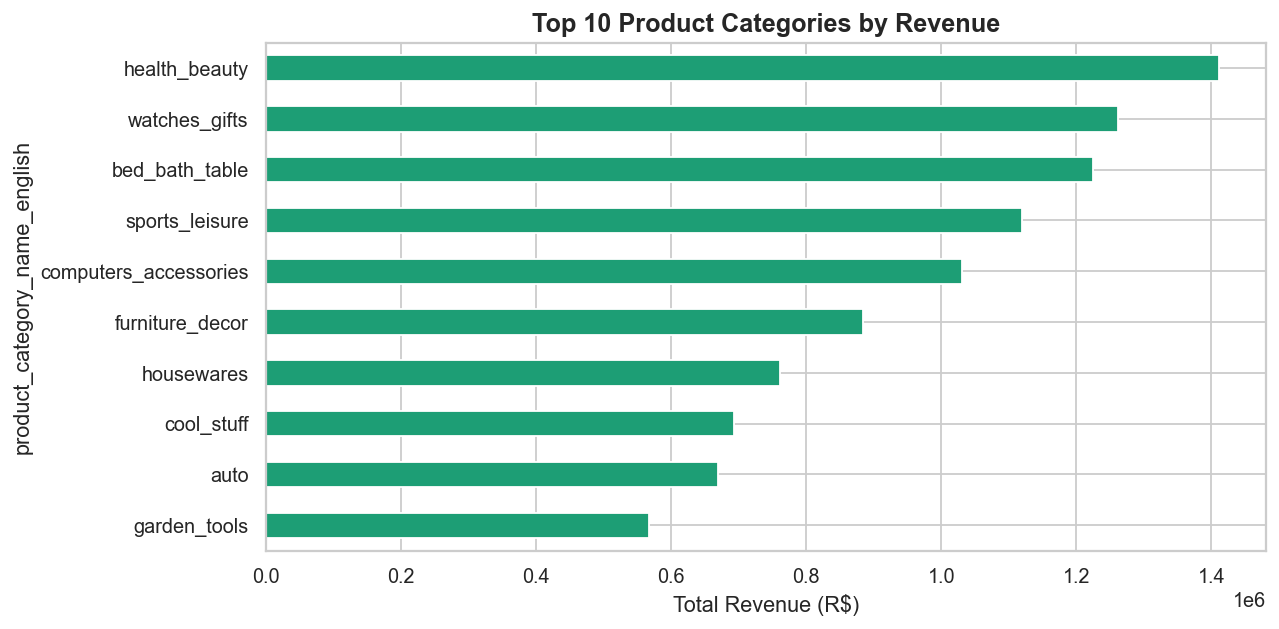

✓ Chart saved!


In [4]:
# Chart 2 - Top 10 Product Categories by Revenue
top_cats = (df.groupby('product_category_name_english')['payment_value']
              .sum().sort_values(ascending=True).tail(10))

fig, ax = plt.subplots(figsize=(10, 5))
top_cats.plot(kind='barh', ax=ax, color='#1D9E75')
ax.set_title('Top 10 Product Categories by Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Revenue (R$)')
plt.tight_layout()
plt.savefig(r'C:\Users\ALG\OneDrive\Documents\olist-ecommerce-analysis\assets\top_categories.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart saved!")

## Finding 2: Health & Beauty is #1 Revenue Category
Health & Beauty generates the highest revenue on the platform,
followed by watches/gifts and bed & bath products.


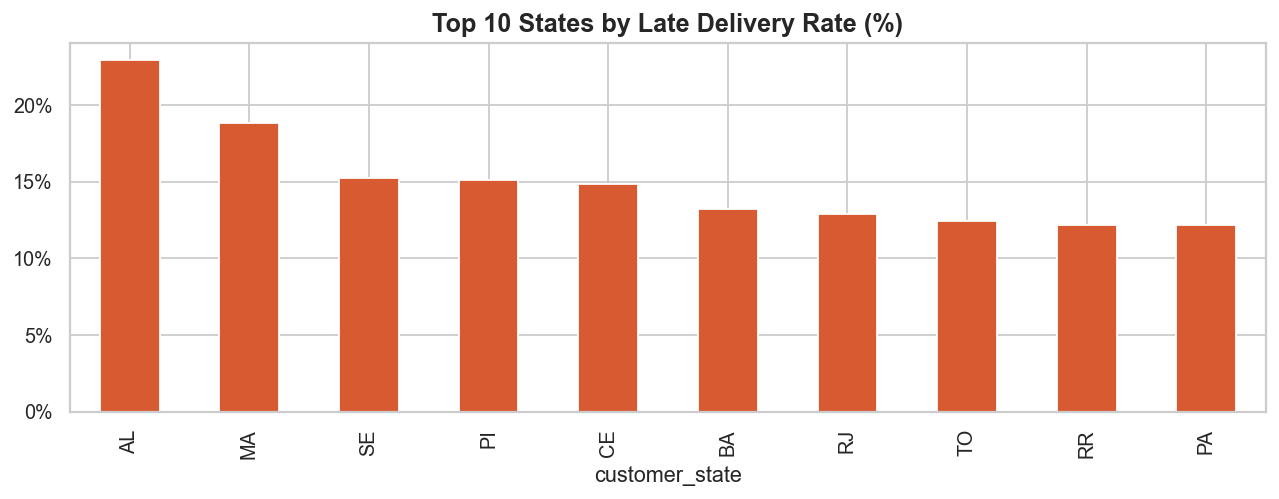

✓ Chart saved!


In [5]:
# Chart 3 - Late Delivery Rate by State
late_state = (df.groupby('customer_state')['late_delivery']
                .mean().sort_values(ascending=False).head(10) * 100)

fig, ax = plt.subplots(figsize=(10, 4))
late_state.plot(kind='bar', ax=ax, color='#D85A30')
ax.set_title('Top 10 States by Late Delivery Rate (%)', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}%'))
plt.tight_layout()
plt.savefig(r'C:\Users\ALG\OneDrive\Documents\olist-ecommerce-analysis\assets\late_delivery_state.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart saved!")

## Finding 3: North-East States Have Worst Delivery Performance
Alagoas (AL) has the highest late delivery rate — likely due to 
distance from São Paulo distribution hubs. This is a logistics 
optimisation opportunity for Olist.

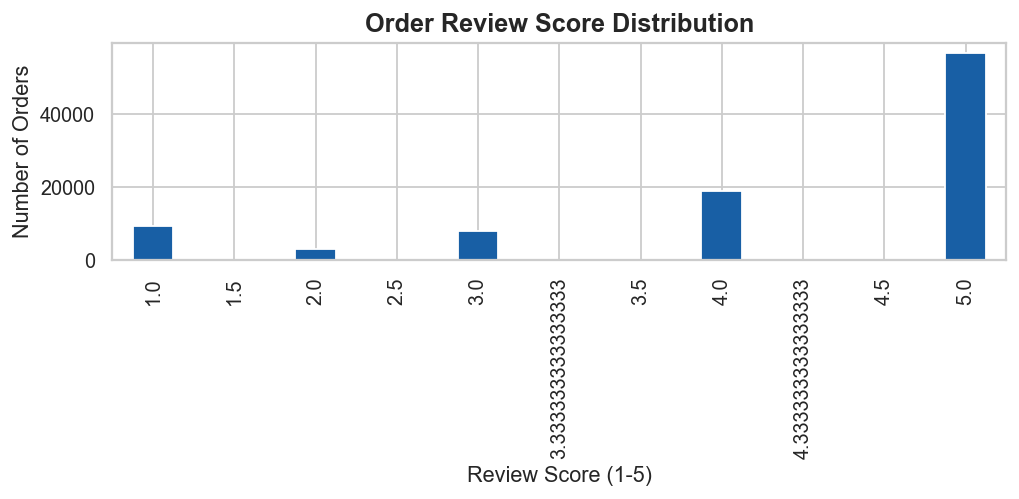

✓ Chart saved!


In [6]:
# Chart 4 - Review Score Distribution
fig, ax = plt.subplots(figsize=(8, 4))
df['review_score'].value_counts().sort_index().plot(
    kind='bar', ax=ax, color='#185FA5', edgecolor='white')
ax.set_title('Order Review Score Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Review Score (1-5)')
ax.set_ylabel('Number of Orders')
plt.tight_layout()
plt.savefig(r'C:\Users\ALG\OneDrive\Documents\olist-ecommerce-analysis\assets\review_scores.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart saved!")

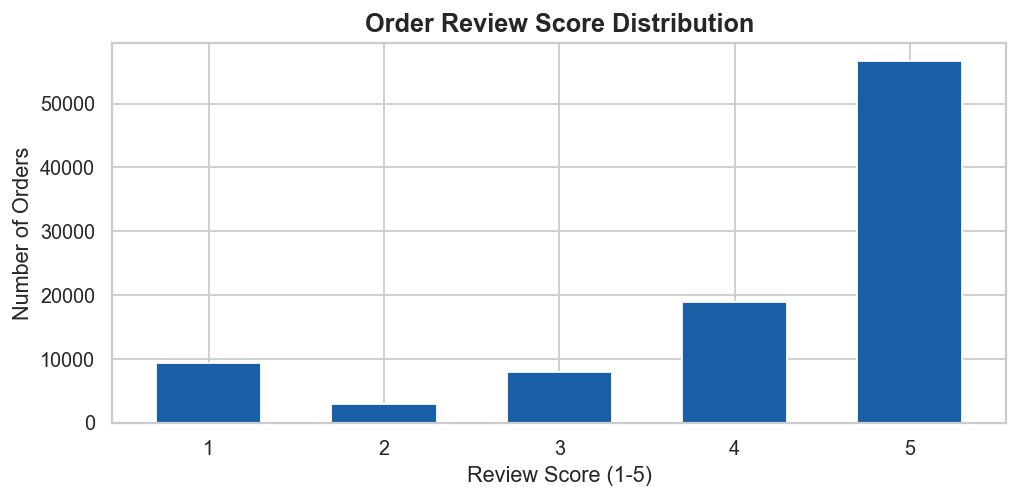

✓ Chart saved!


In [7]:
# Chart 4 Fixed - Review Score Distribution
fig, ax = plt.subplots(figsize=(8, 4))
df['review_score'].dropna().astype(int).value_counts().sort_index().plot(
    kind='bar', ax=ax, color='#185FA5', edgecolor='white', width=0.6)
ax.set_title('Order Review Score Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Review Score (1-5)')
ax.set_ylabel('Number of Orders')
ax.set_xticklabels(['1','2','3','4','5'], rotation=0)
plt.tight_layout()
plt.savefig(r'C:\Users\ALG\OneDrive\Documents\olist-ecommerce-analysis\assets\review_scores.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart saved!")

## Finding 4: Customers Are Generally Happy
Over 50,000 orders received 5-star reviews — the majority of customers 
are satisfied. However, ~11,000 orders received 1-star reviews, 
worth investigating for patterns with late deliveries.